# Top Catalogs: Tang Dynasty vs Roman Empire

This notebook shows the top-10 external identifier catalogues referencing individuals
in the Tang Dynasty and the Roman Empire. All data comes from the SQLite3 database.

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
DB = DB_PATH


## Query top-10 catalogs for Tang Dynasty and Roman Empire

We query `individuals_cliopatria` joined to `identifiers` and `identifier_types`
to count which catalogues reference the most individuals in each polity.

In [ ]:
conn = duckdb.connect(DB, read_only=True)
polity_catalogs = {}
for label, where in [('Tang Dynasty', "ic.polity_name LIKE 'Tang Dynasty%'"),
                      ('Roman Empire', "ic.polity_name LIKE 'Roman Empire%' AND ic.polity_name NOT LIKE '%Holy%'")]:
    cur = conn.execute(f'''
        SELECT it.property_id, it.name_en, it.country_name,
               COUNT(DISTINCT ic.wikidata_id) AS n
        FROM individuals_cliopatria ic
        JOIN identifiers i ON ic.wikidata_id = i.wikidata_id
        JOIN identifier_types it ON i.property_id = it.property_id
        WHERE {where}
        GROUP BY it.property_id, it.name_en, it.country_name
        ORDER BY n DESC
        LIMIT 10
    ''')
    rows = [(pid, name, cnt, co) for pid, name, co, cnt in cur.fetchall()]
    polity_catalogs[label] = rows

conn.close()

In [4]:
for label, items in polity_catalogs.items():
    df_pol = pd.DataFrame(items, columns=['property_id', 'catalog', 'count', 'country'])
    print(f"\n{label} — top 10 catalogs:")
    display(df_pol)


Tang Dynasty — top 10 catalogs:


,property_id,catalog,count,country
0,P497,CBDB ID,36778,NaN
1,P6702,Shanghai Library person ID,36631,NaN
2,P2600,Geni.com profile ID,6598,NaN
3,P2671,Google Knowledge Graph ID,2962,NaN
4,P9613,ctext data entity ID,1675,NaN
5,P13591,Yale LUX ID,764,NaN
6,P646,Freebase ID,744,NaN
7,P214,VIAF cluster ID,406,NaN
8,P10565,Encyclopedia of China (Third Edition) ID,318,People's Republic of China
9,P244,Library of Congress authority ID,308,United States



Roman Empire — top 10 catalogs:


,property_id,catalog,count,country
0,P646,Freebase ID,2405,NaN
1,P2671,Google Knowledge Graph ID,2282,NaN
2,P214,VIAF cluster ID,1555,NaN
3,P227,GND ID,1375,Germany
4,P1871,CERL Thesaurus ID,1084,NaN
5,P7902,Deutsche Biographie (GND) ID,1032,NaN
6,P244,Library of Congress authority ID,888,United States
7,P213,ISNI,808,NaN
8,P13049,DDB person (GND) ID,807,NaN
9,P8069,ToposText person ID,777,NaN


### Side-by-side bar charts for Tang Dynasty and Roman Empire

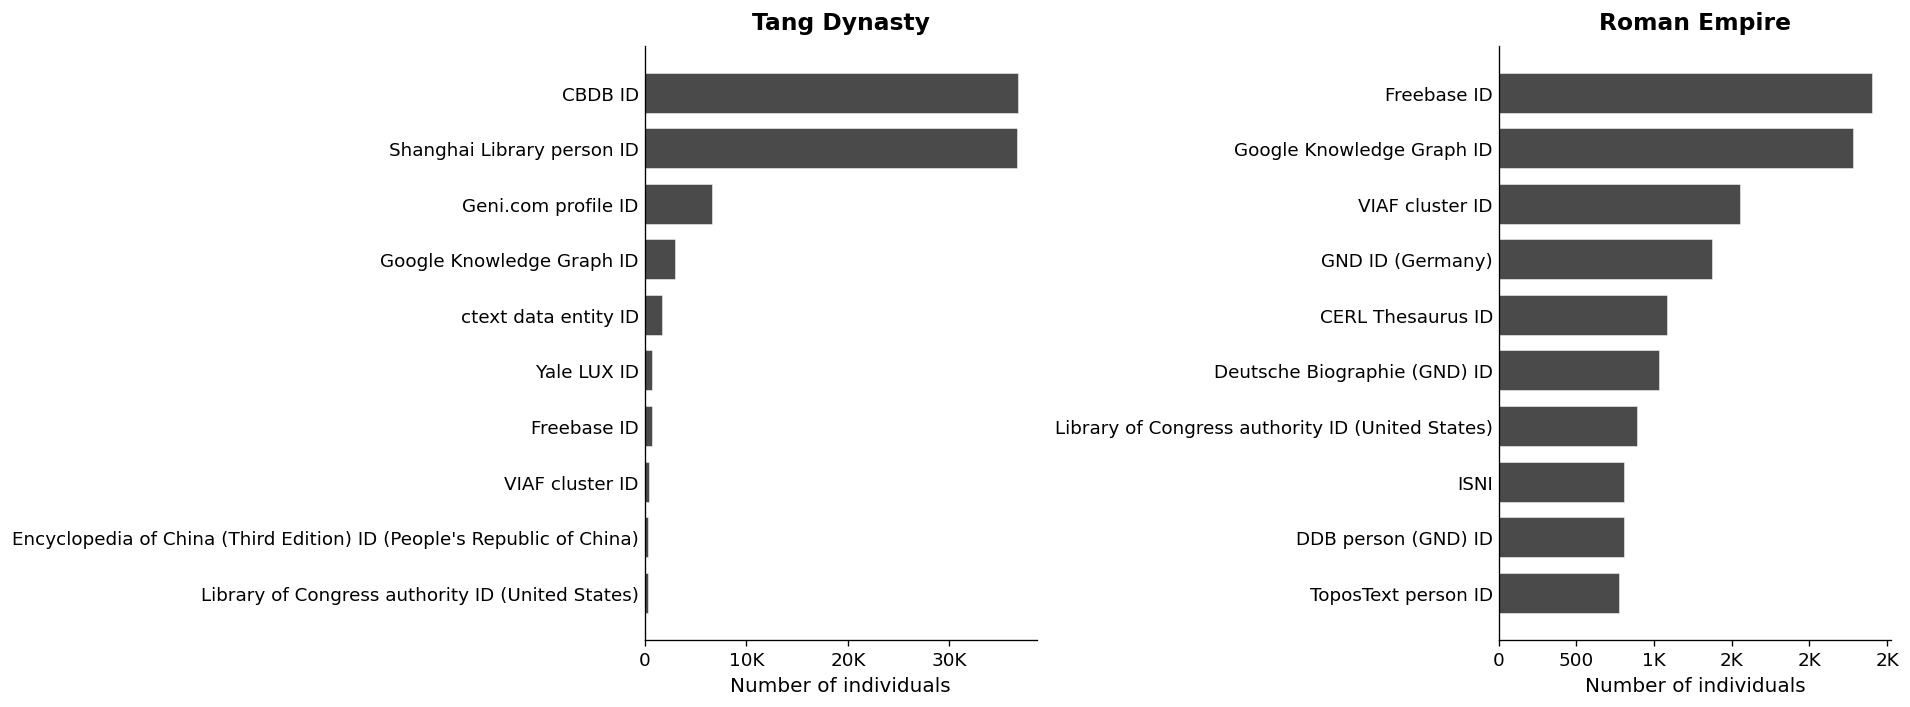

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, label in [(ax1, 'Tang Dynasty'), (ax2, 'Roman Empire')]:
    items = list(reversed(polity_catalogs[label]))
    labels = [f"{n} ({co})" if co else n for _, n, _, co in items]
    values = [c for _, _, c, _ in items]
    y = np.arange(len(items))

    ax.barh(y, values, height=0.72, color='#4a4a4a', edgecolor='white', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Number of individuals', fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
    ))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', length=0)
    ax.set_title(label, fontsize=14, fontweight='bold', color='black', pad=10)

plt.tight_layout()
plt.show()